In [1]:
'''
This notebook is used to do explore and visualize some of the relationship between anthro features vs positons
NB also models how important anthro features are to performance
'''

'\nThis notebook is used to do explore and visualize some of the relationship between anthro features vs positons\nNB also models how important anthro features are to performance\n'

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import os
import seaborn as sns
from scipy import stats
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler # normalize graphs --> easier to viz.

In [3]:
# Paths

try:
    main_directory = Path(__file__).parent
except NameError:
    main_directory = Path(os.path.dirname(os.getcwd()))  # fallback for Jupyter

data_folder = main_directory / 'data' # data folder output
notebook_folder = main_directory / 'notebooks' 
results_folder = main_directory / 'results'

In [4]:
# Just put it here for now
scaler = MinMaxScaler()

In [5]:
# Model data


df_def = pd.read_csv(data_folder / 'def_model_data.csv')
df_qb = pd.read_csv(data_folder / 'qb_model_data.csv')
df_wr = pd.read_csv(data_folder / 'wr_model_data.csv')
df_rb = pd.read_csv(data_folder/ 'rb_model_data.csv')
df_roster = pd.read_csv(data_folder/'roster_model_data.csv')

In [6]:
# combine all and keep anthro data + positions - for comparisons

df_all_pos = pd.concat([df_def, df_qb, df_wr, df_rb], ignore_index=True)

df_all_pos['position_source'] = np.select(
    [
        df_all_pos['passer_player_id'].notna(),
        df_all_pos['rusher_player_id'].notna(),
        df_all_pos['receiver_player_id'].notna(),
        df_all_pos['defender_id'].notna()
    ],
    ['qb', 'rb', 'wr', 'def'],
    default='unknown'
) # get source of row data

df_all_pos['bmi'] = (df_all_pos['weight_lbs']/df_all_pos['height_in']**2) * 703 # Get bmi

# df_all_pos['id'] = df_all_pos['defender_id'].fillna(df_all_pos['passer_player_id']).fillna(df_all_pos['receiver_player_id']).fillna(df_all_pos['rusher_player_id']) # get single player_id col
# Just anthro features + season
# df_all_pos_anthro = df_all_pos[['id', 'season', 'position_group', 'md_weight_lbs', 'md_height_in']] # Just anthro features + season
# df_all_pos_anthro['bmi'] = df_all_pos_anthro['weight (lbs)']/df_all_pos_anthro['height (in)']**2
# # anthro features + epa + season
# df_all_pos_ = df_all_pos[['season', 'position_group', 'md_weight_lbs', 'md_height_in']] # Just anthro features + season

In [7]:
# Number of rows per position
print(df_all_pos['position_source'].value_counts())

position_source
wr     2949
def    2203
rb     1464
qb     1109
Name: count, dtype: int64


In [8]:
# Number of unique players in each positioon

df_count =  df_all_pos.drop_duplicates(subset=['gsis_id','position_source'])
print(df_count['position_source'].value_counts())

position_source
wr     676
def    516
rb     359
qb     205
Name: count, dtype: int64


## EDA

In [ ]:

measurement_list = ['weight_lbs', 'height_in', 'bmi', 'arm_length_in','wing_span_in','hand_size_in'] 
pos_order = ['lb', 'db', 'dl', 'qb', 'wr', 'te', 'rb'] # Order for graphs
position_config = {
    'qb':  {'df': df_all_pos[df_all_pos['position_source'] == 'qb'],  'player_id': 'passer_player_id',  'target': 'epa_per_dropback'},
    'rb':  {'df': df_all_pos[df_all_pos['position_source'] == 'rb'],  'player_id': 'rusher_player_id',  'target': 'epa_per_rush'},
    'wr':  {'df': df_all_pos[df_all_pos['position_source'] == 'wr'],  'player_id': 'receiver_player_id','target': 'epa_per_target'},
    'def': {'df': df_all_pos[df_all_pos['position_source'] == 'def'], 'player_id': 'defender_id',       'target': 'def_epa_per_play'},
} # position to target relevant info

df_graph = df_all_pos.drop_duplicates(subset=['gsis_id']).copy() # Unique values for height vs weight comparisons

In [10]:
df_graph.to_csv('test.csv')

## Height and Weight by Position

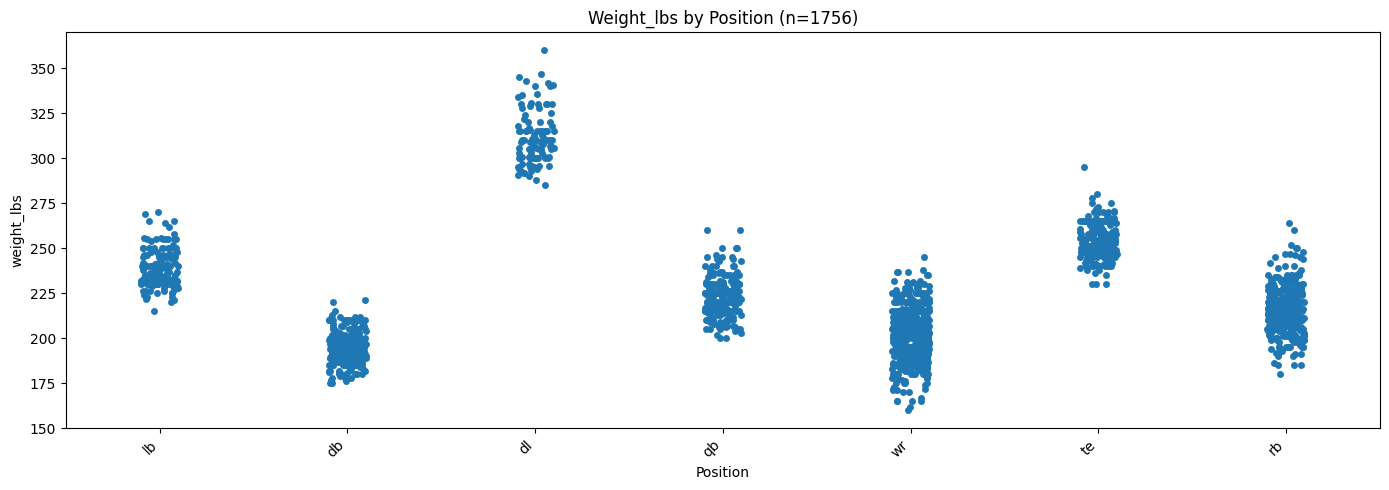

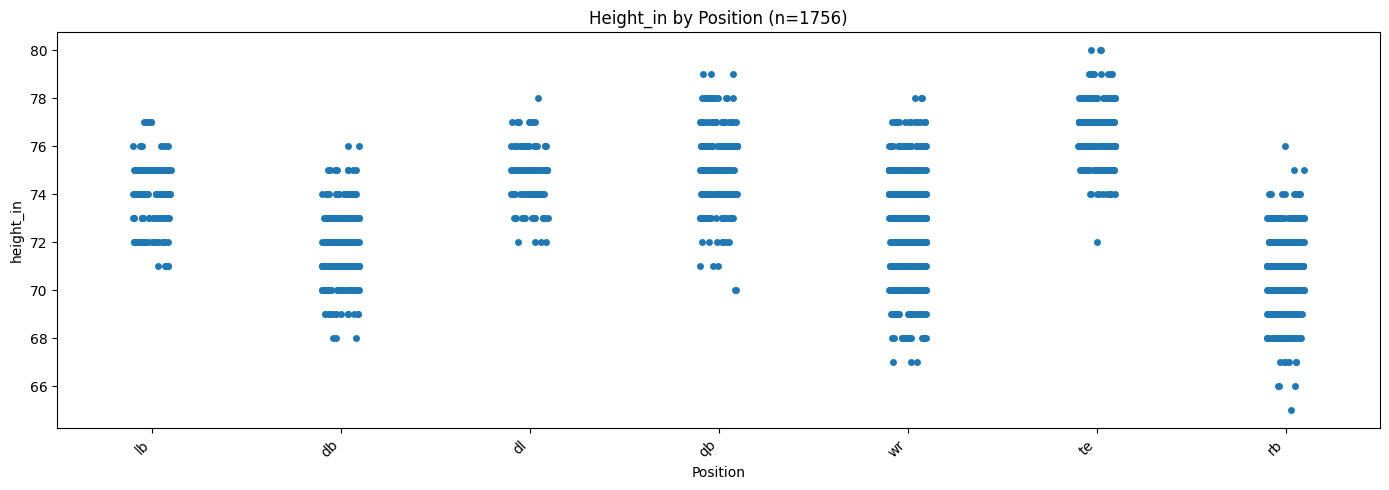

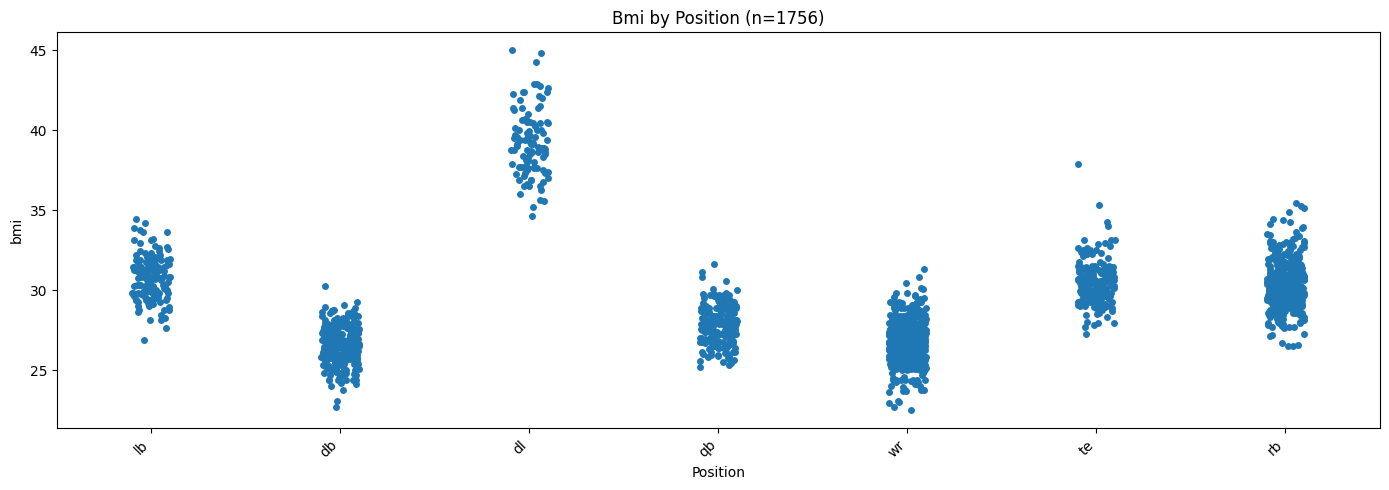

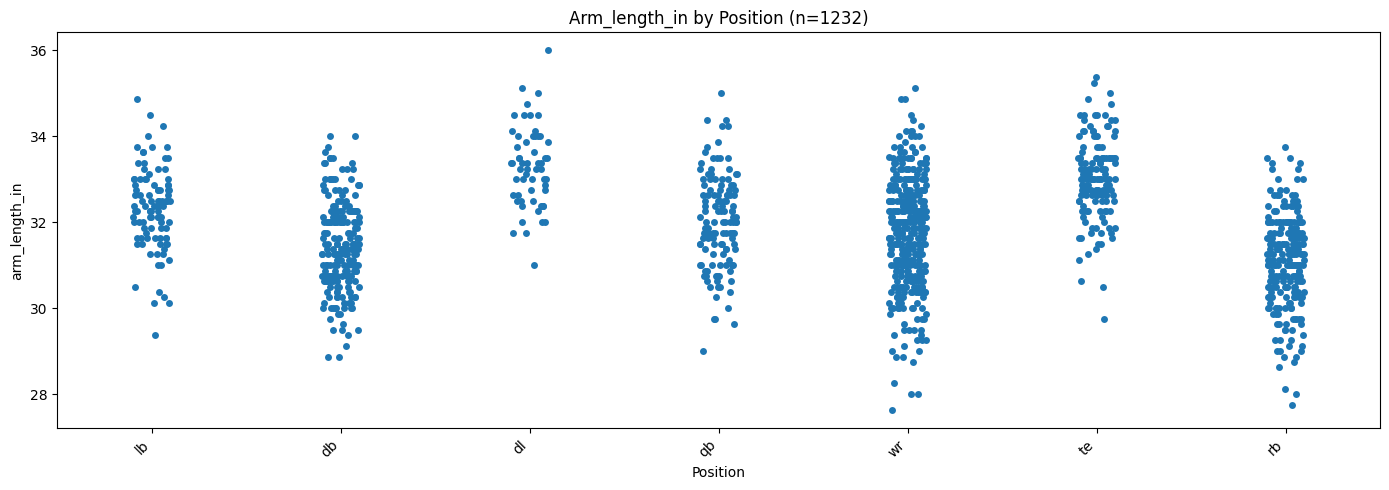

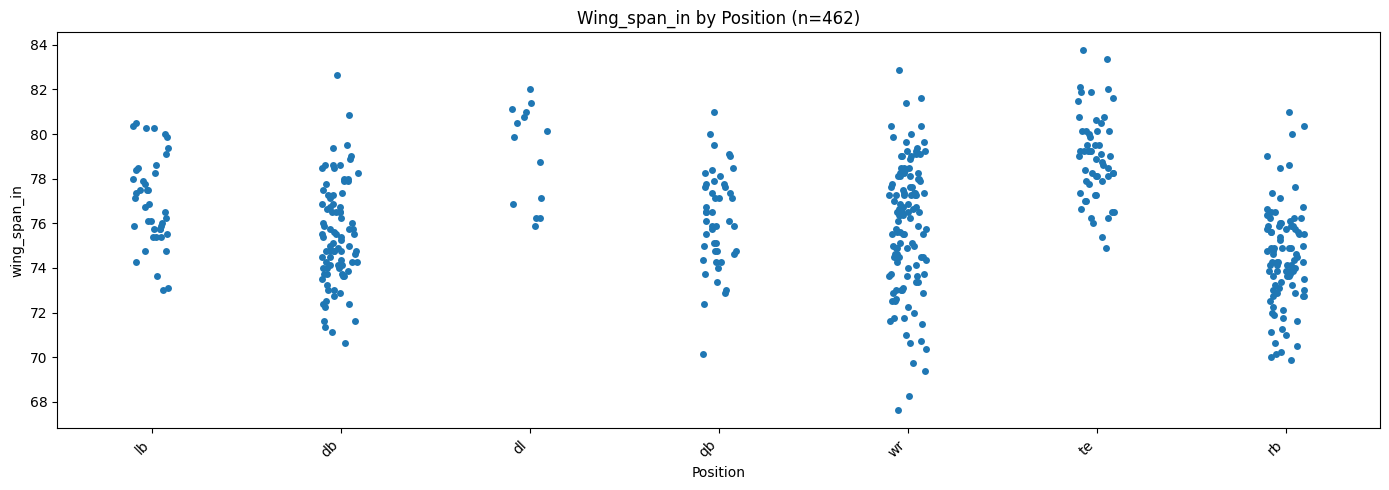

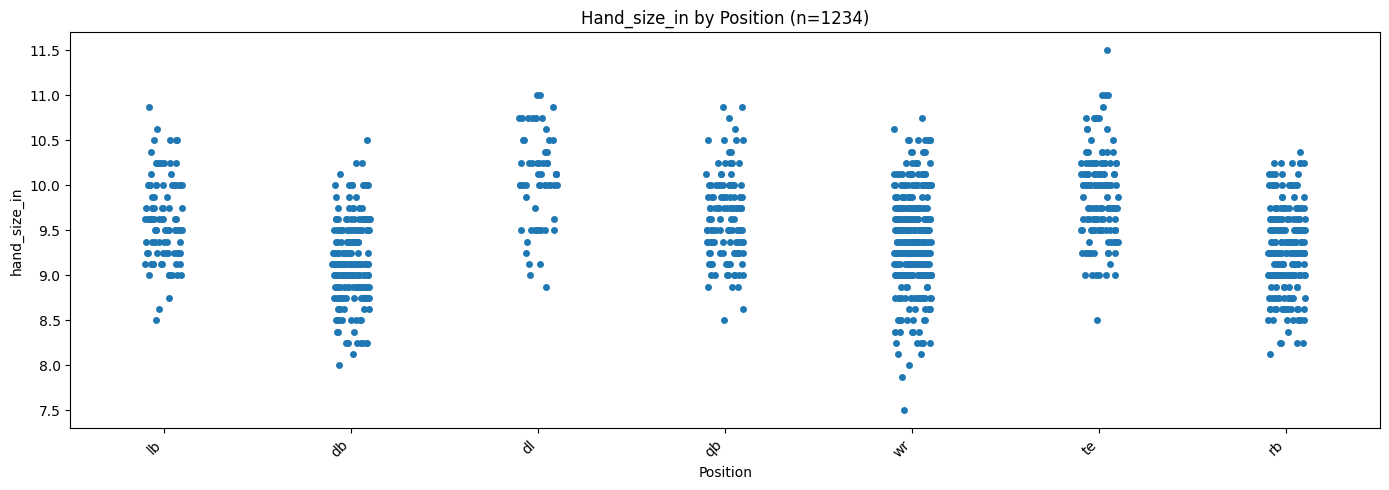

In [11]:
for measurement in measurement_list:
    total_obs = df_graph[measurement].notna().sum()
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.stripplot(x='position_group', y=measurement, data=df_graph, order=pos_order, ax=ax)
    ax.set_title(f'{measurement.capitalize()} by Position (n={total_obs})')
    ax.set_xlabel('Position')
    ax.set_ylabel(measurement)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(results_folder/f'{measurement.lower()}_by_position.png')
    plt.show()

## Outlier detection by Group

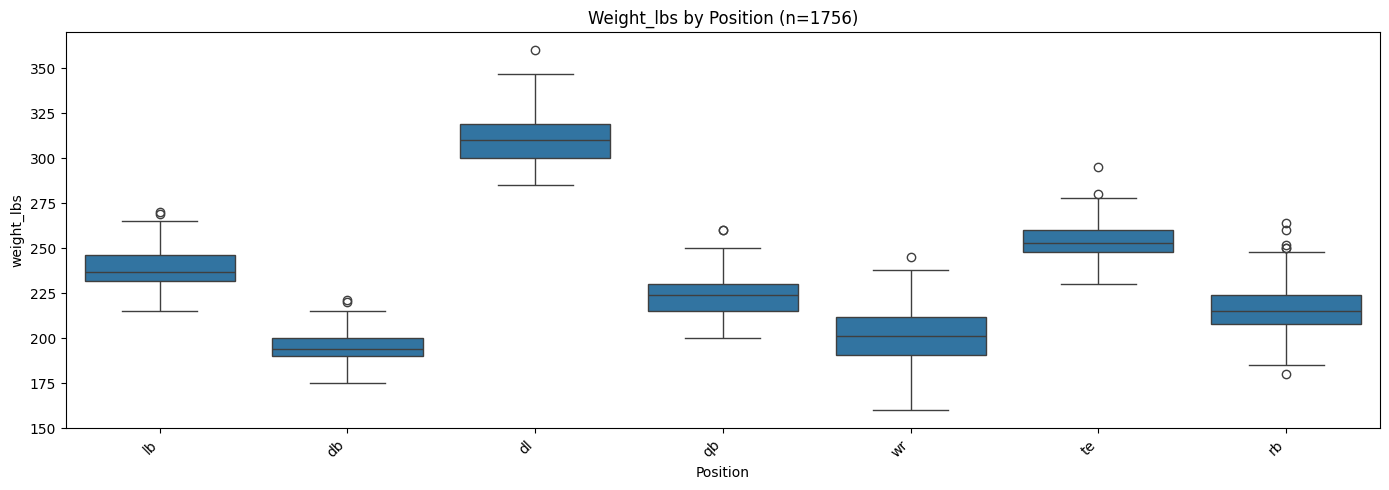

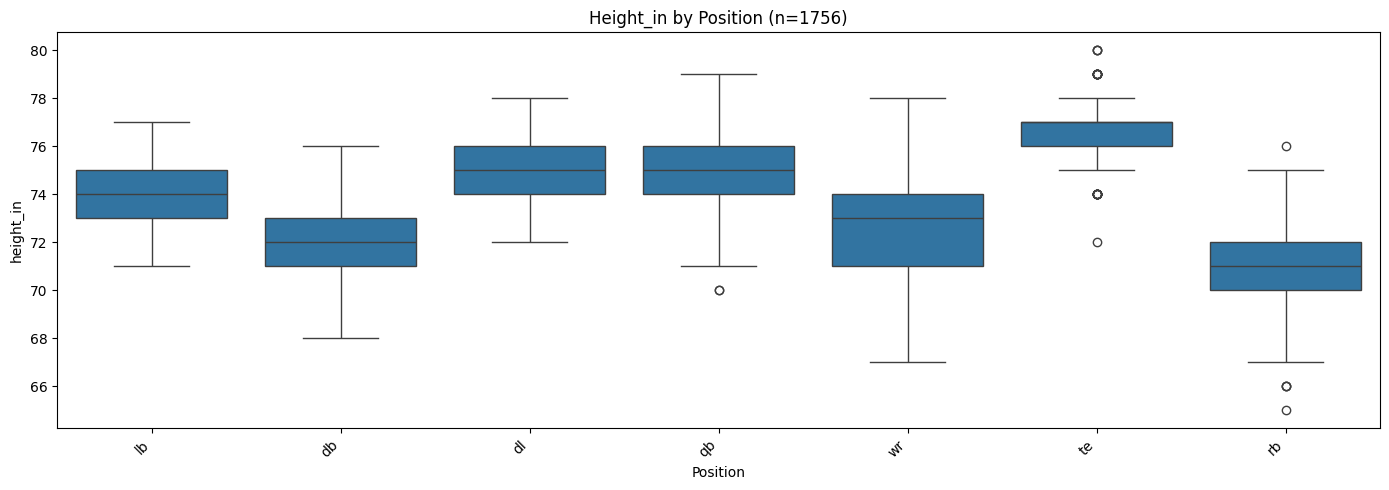

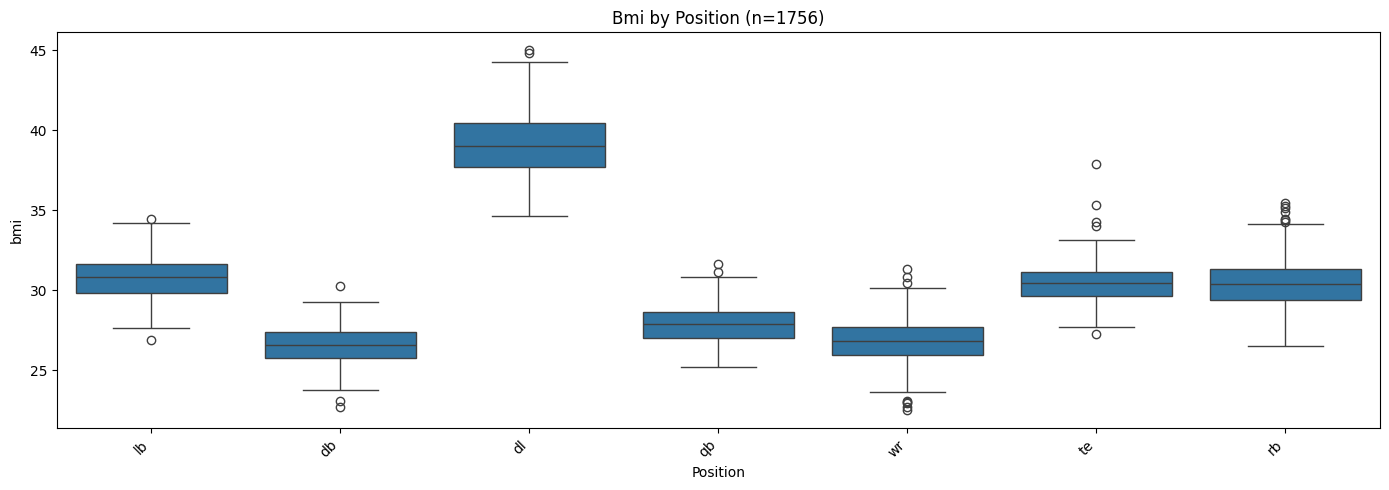

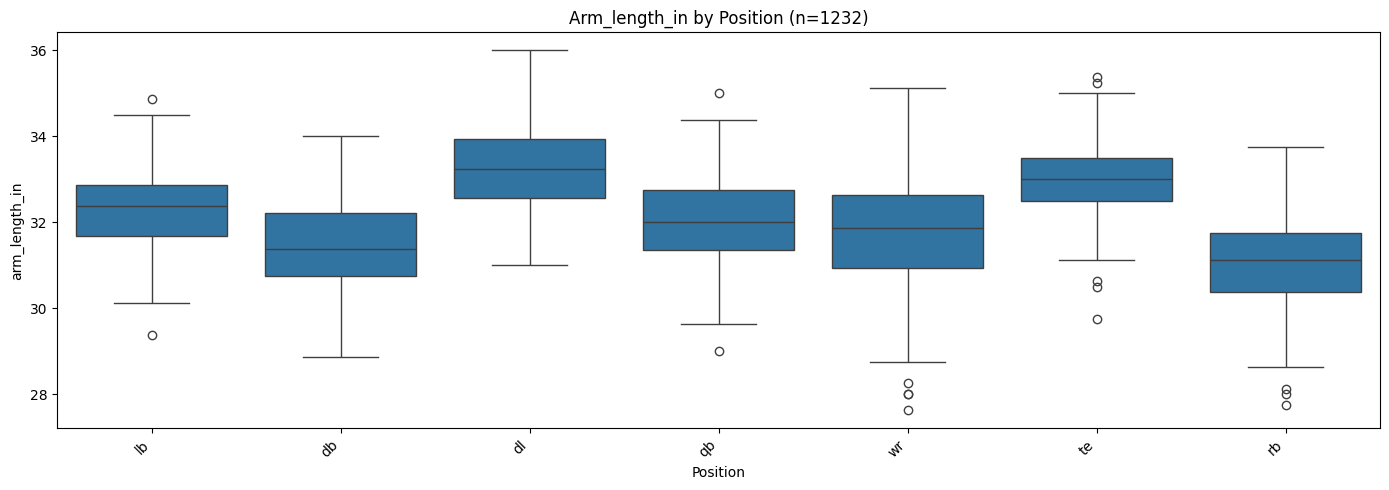

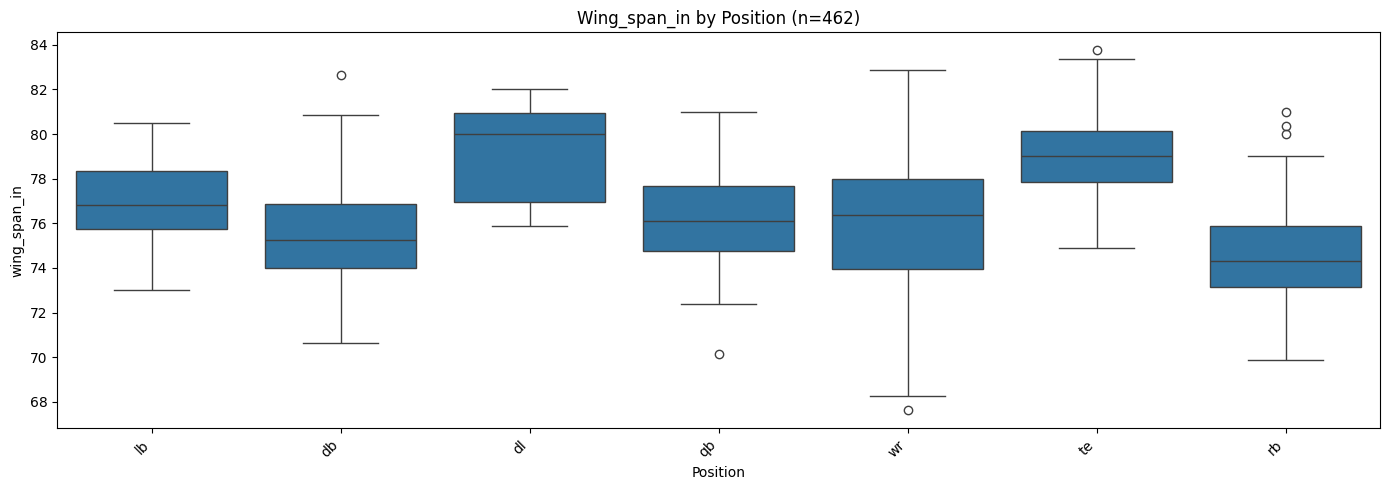

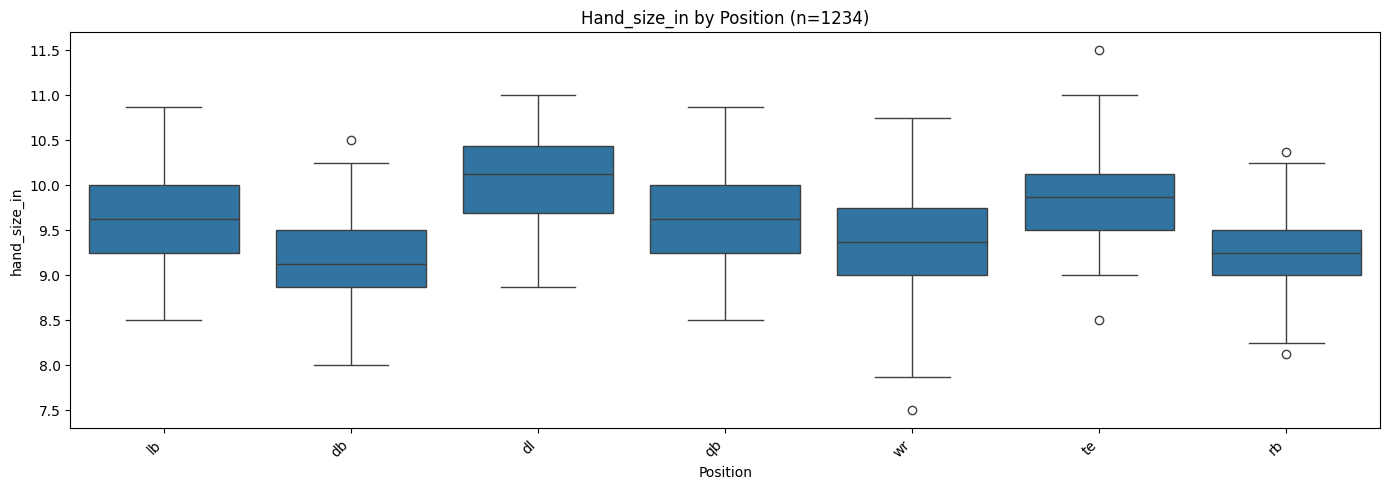

In [12]:
for measurement in measurement_list: 
    total_obs = df_graph[measurement].notna().sum()
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(x='position_group', y=measurement, data=df_graph, order=pos_order, ax=ax)
    ax.set_title(f'{measurement.capitalize()} by Position (n={total_obs})')
    ax.set_xlabel('Position')
    ax.set_ylabel(measurement)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(results_folder/f'boxplots_{measurement.lower()}_by_position.png')
    plt.show()



In [13]:
def count_outliers(x):
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    return ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum()

for measurement in measurement_list: 

    
    if measurement == 'bmi':
        outlier_counts = df_graph.groupby('position_group')[measurement].apply(count_outliers)
        total_obs = df_graph[measurement].count()
    else:
        outlier_counts = df_graph[df_graph[f'missing_{measurement}'] != 1].groupby('position_group')[measurement].apply(count_outliers)
        total_obs = df_graph[measurement][df_graph[f'missing_{measurement}'] != 1][df_graph[f'missing_{measurement}'] != 1].count()
        
    outlier_counts = df_graph.groupby('position_group')[measurement].apply(count_outliers)
    total_counts = df_graph.groupby('position_group')[measurement].count()
    
    summary = pd.DataFrame({
        'outlier_count': outlier_counts,
        'total_count': total_counts,
        'outlier_pct': (outlier_counts / total_counts * 100).round(1)
    }).sort_values('outlier_pct', ascending=False)
    
    print(f"\n{measurement.capitalize()}:\n", summary.to_string())


Weight_lbs:
                 outlier_count  total_count  outlier_pct
position_group                                         
rb                          6          359          1.7
lb                          2          144          1.4
dl                          1          103          1.0
te                          2          204          1.0
qb                          2          205          1.0
db                          2          269          0.7
wr                          1          472          0.2

Height_in:
                 outlier_count  total_count  outlier_pct
position_group                                         
te                         23          204         11.3
rb                          5          359          1.4
qb                          2          205          1.0
lb                          0          144          0.0
dl                          0          103          0.0
db                          0          269          0.0
wr                   

In [14]:
summary.to_csv(results_folder/'outlier_table.csv', index=False)

## Trend Analysis over Seasons

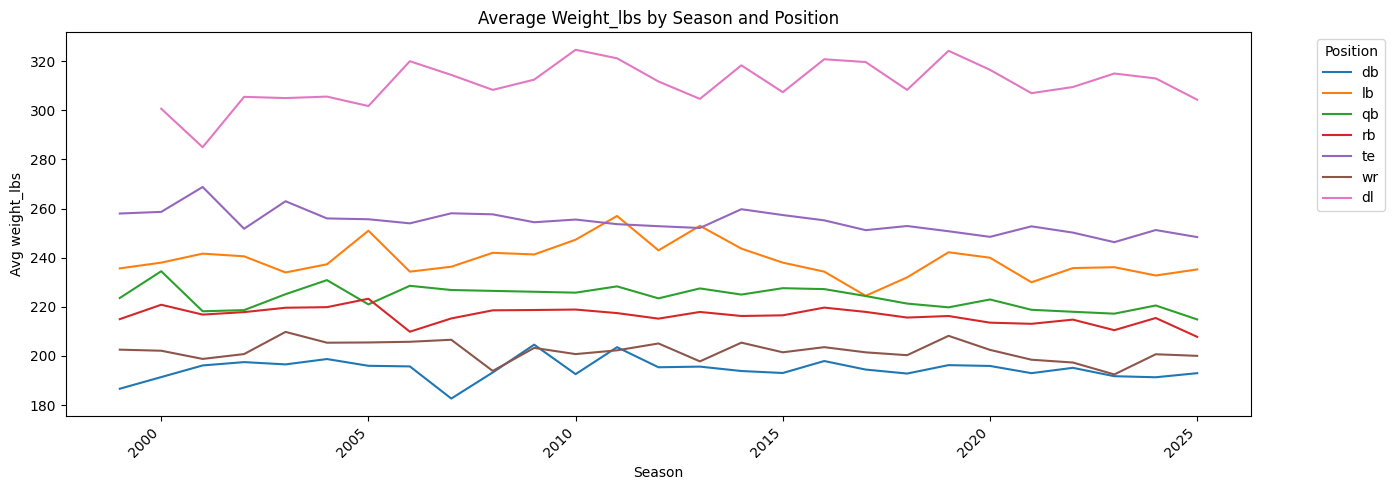

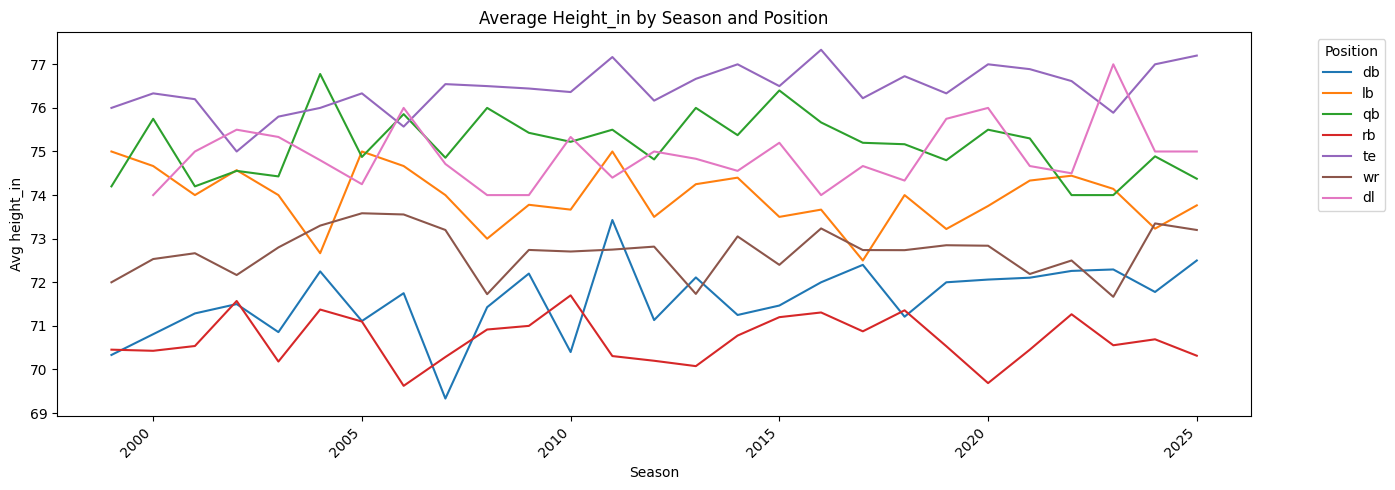

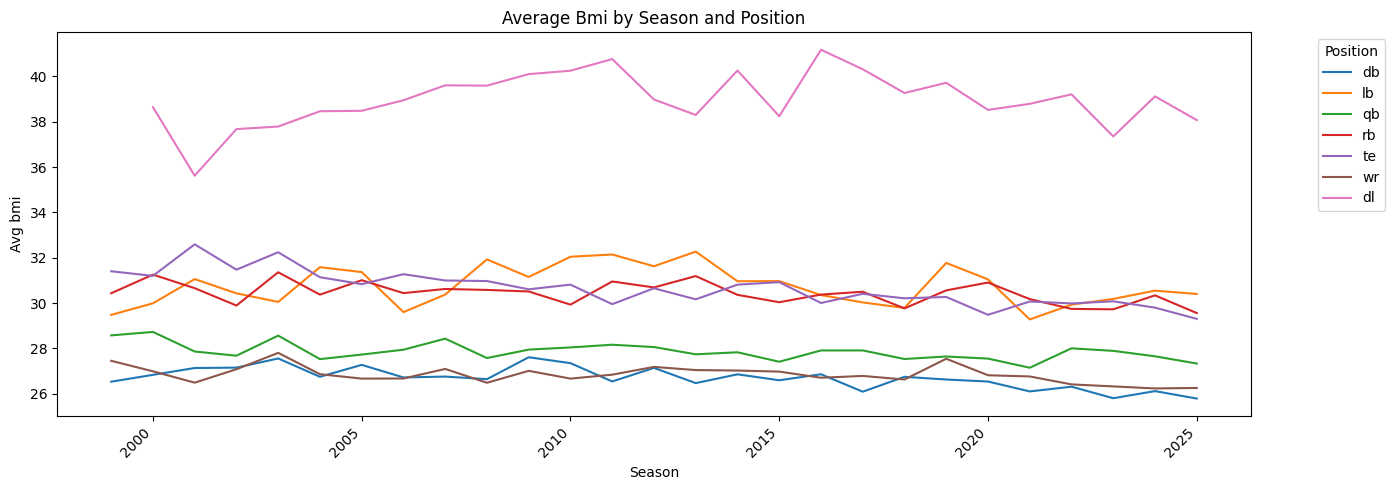

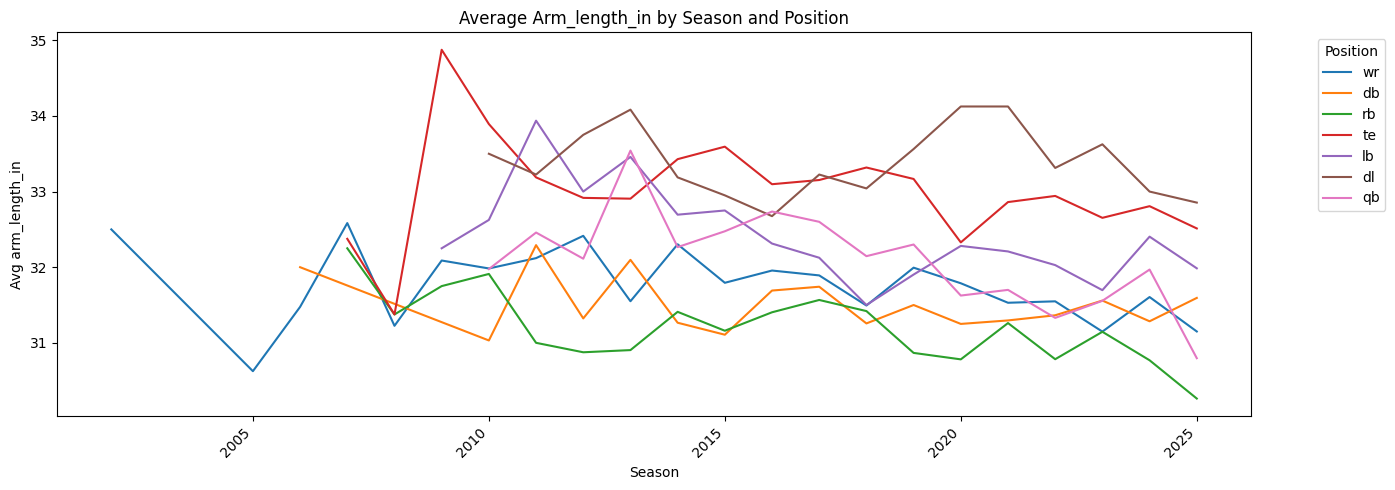

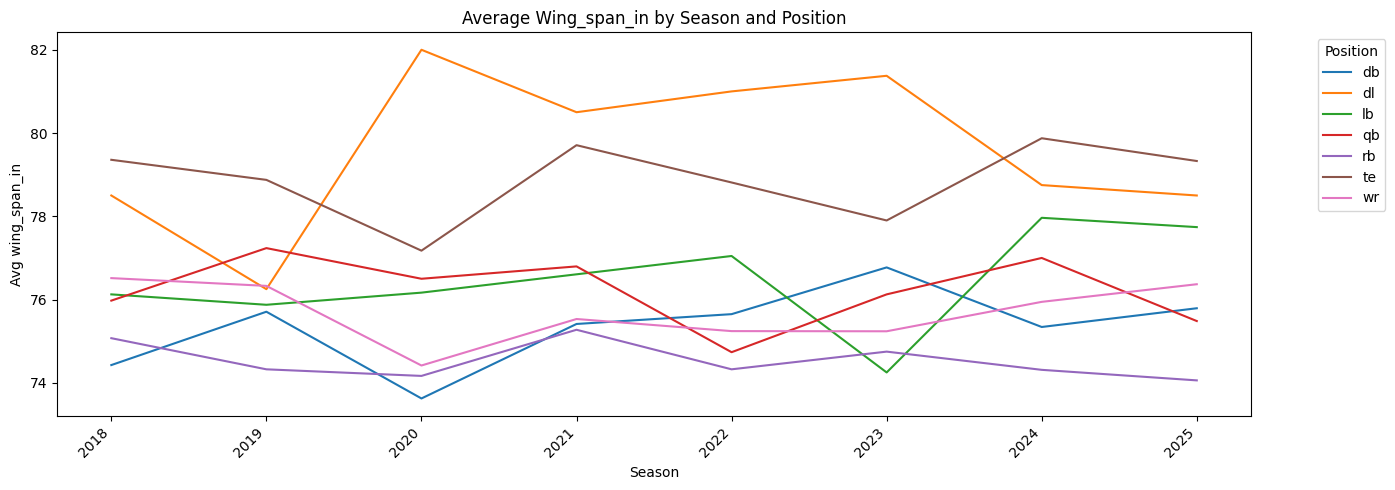

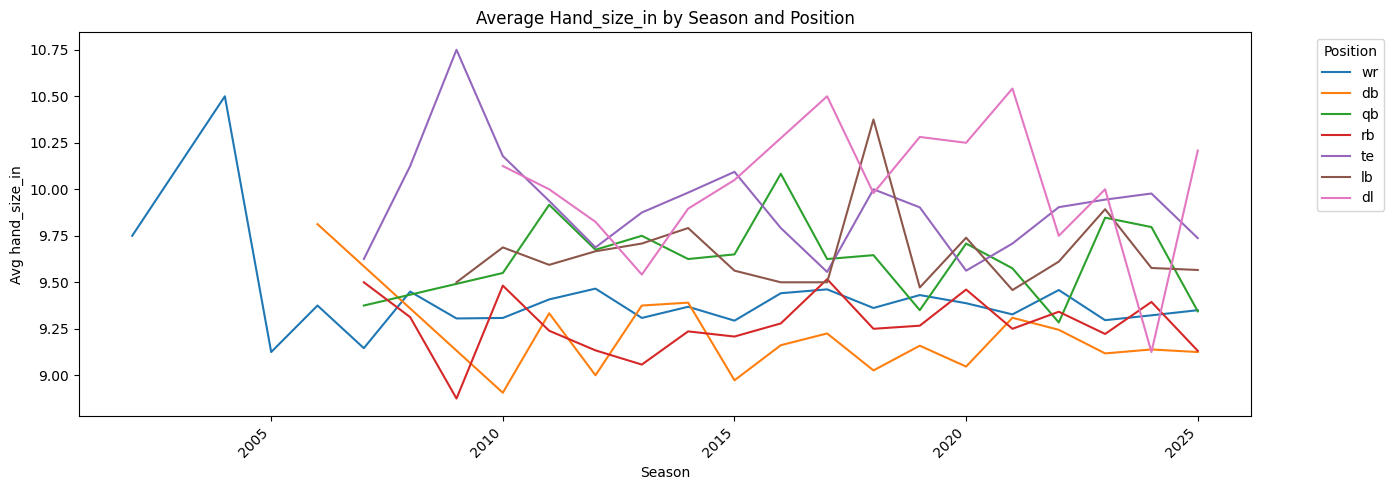

In [15]:
for measurement in measurement_list:
    df_sns = df_graph[df_graph[measurement].notna()].copy()
    df_sns = df_sns.drop_duplicates(subset=['gsis_id', 'season'])
    
    season_avg = df_sns.groupby(['season', 'position_group'])[measurement].mean().reset_index()
    
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.lineplot(x='season', y=measurement, hue='position_group', data=season_avg, ax=ax)
    ax.set_title(f'Average {measurement.capitalize()} by Season and Position')
    ax.set_xlabel('Season')
    ax.set_ylabel(f'Avg {measurement}')
    # ax.set_ylim(bottom=0)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(results_folder/f'avg_{measurement.lower()}_season_pos.png')
    plt.show()

## Correlation - Roster

In [16]:
df_roster.head()

,team,season,team_avg_height,team_avg_weight,pass_epa,dropbacks,rush_epa,rush_attempts,total_off_plays,off_epa_per_play,...,dropbacks_faced,rush_epa_allowed,rush_attempts_faced,total_def_plays,def_epa_per_play,team_qb_epa,off_epa_prior,def_epa_prior,first_season_flag,net_epa_per_play
0,ARI,1999,74.671875,254.859375,-117.134066,604.0,-72.284747,396.0,1000.0,-0.189419,...,532.0,-5.724189,542.0,1074.0,-0.012730,NaN,NaN,NaN,1,-0.176689
1,ARI,2000,74.323944,251.197183,-69.705888,597.0,-70.759920,346.0,943.0,-0.148956,...,487.0,32.539719,579.0,1066.0,0.111125,NaN,-0.189419,-0.012730,0,-0.260082
2,ARI,2001,74.153846,247.046154,31.898784,571.0,-63.029843,401.0,972.0,-0.032028,...,591.0,-22.647174,497.0,1088.0,0.024941,NaN,-0.148956,0.111125,0,-0.056969
3,ARI,2016,74.245098,243.166667,9.804531,692.0,-33.140294,399.0,1091.0,-0.021389,...,621.0,-63.719302,424.0,1045.0,-0.093461,0.010240,0.101693,-0.095615,0,0.072072
4,ARI,2017,74.173077,239.846154,-92.926690,667.0,-81.773024,409.0,1076.0,-0.162360,...,623.0,-63.937718,409.0,1032.0,-0.102575,-0.143737,-0.021389,-0.093461,0,-0.059786


In [17]:

measurement_list_team = ['team_avg_height', 'team_avg_weight'] 

targets_team = ['net_epa_per_play', 'off_epa_per_play', 'def_epa_per_play'] 

df_team_graph = df_roster.copy()


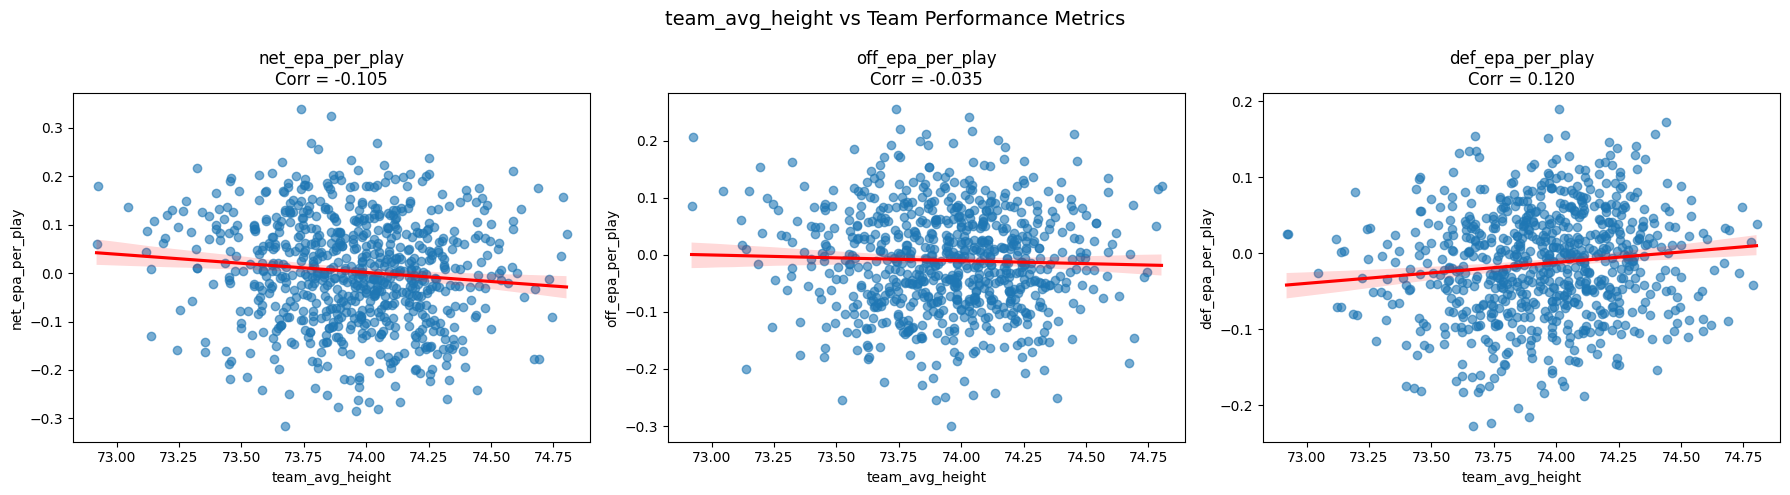

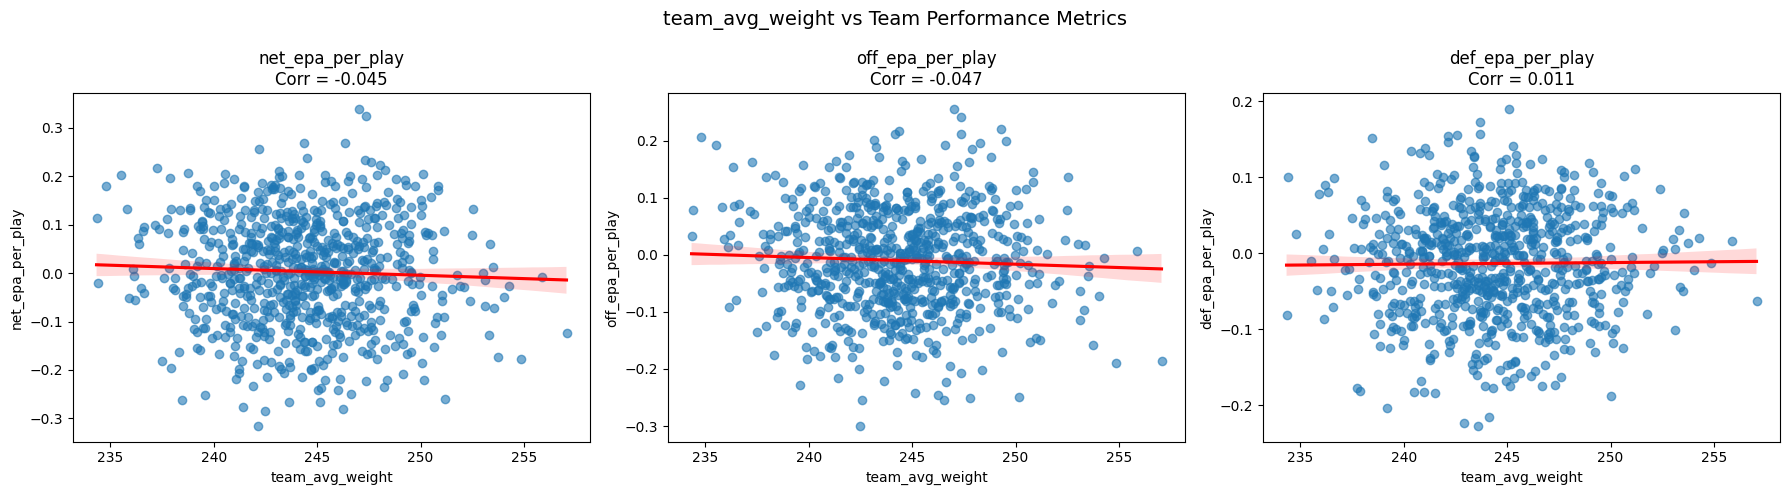

In [18]:


for measurement in measurement_list_team:
    
    fig, axes = plt.subplots(1, len(targets_team), figsize=(18, 5))
    
    for i, target in enumerate(targets_team):
        ax = axes[i]
        
        # Drop NaNs per pair
        df_plot = df_team_graph[[measurement, target]].dropna()
        
        # Scatter + trend line
        sns.regplot(
            data=df_plot,
            x=measurement,
            y=target,
            ax=ax,
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'}
        )
        
        corr = df_plot[measurement].corr(df_plot[target])
        
        ax.set_title(f"{target}\nCorr = {corr:.3f}")
        ax.set_xlabel(measurement)
        ax.set_ylabel(target)
    
    plt.suptitle(f"{measurement} vs Team Performance Metrics", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{results_folder}/team_{measurement}_performance.png")
    plt.show()

In [19]:
print(len(measurement_list))

6


In [ ]:
# corr_results = {}
# for model in position_config:
#     corr_results_pos = {}
#     position = model
#     target = position_config[model]['target']

#     df_corr = df_graph.copy()
#     df_corr = df_corr[df_corr['position_source'] == model]
#     for measurement in measurement_list:
#         corr_measurements = df_corr[measurement].corr(df_corr[target])
#         corr_results_pos[measurement] = corr_measurements 

#     corr_results[position] = corr_results_pos


In [ ]:
# display(corr_results)

{'qb': {'weight_lbs': np.float64(0.13663393465485676),
  'height_in': np.float64(0.07584596640987258),
  'bmi': np.float64(0.07673359592945114),
  'arm_length_in': np.float64(0.17881588247206828),
  'wing_span_in': np.float64(0.08115159933183277),
  'hand_size_in': np.float64(0.16239583848466188)},
 'rb': {'weight_lbs': np.float64(0.04545899409734826),
  'height_in': np.float64(0.04013191613928987),
  'bmi': np.float64(0.013404586473335742),
  'arm_length_in': np.float64(0.05982680190769453),
  'wing_span_in': np.float64(-0.03779767709748863),
  'hand_size_in': np.float64(0.10760751264296181)},
 'wr': {'weight_lbs': np.float64(0.048941578976319816),
  'height_in': np.float64(0.04441692760890857),
  'bmi': np.float64(0.03914873596594626),
  'arm_length_in': np.float64(-0.034700413335020434),
  'wing_span_in': np.float64(0.010314851895772569),
  'hand_size_in': np.float64(0.012100431796295257)},
 'def': {'weight_lbs': np.float64(0.763997776140164),
  'height_in': np.float64(0.50491906335

# Models

In [22]:
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer


## Anthro features for players

In [23]:
df_def = pd.read_csv(data_folder / 'def_model_data.csv')
df_qb = pd.read_csv(data_folder / 'qb_model_data.csv')
df_wr = pd.read_csv(data_folder / 'wr_model_data.csv')
df_rb = pd.read_csv(data_folder/ 'rb_model_data.csv')

In [24]:
model_config = {
    'qb':  {'df': df_qb,  'player_id': 'passer_player_id',  'target': 'qb_epa_per_dropback', 'drop_cols' : ['passing_epa', 'qb_epa', 'dropbacks', 'epa_per_dropback']},
    'rb':  {'df': df_rb,  'player_id': 'rusher_player_id',  'target': 'epa_per_rush', 'drop_cols': ['rushing_epa', 'rush_attempts']},
    'wr':  {'df': df_wr,  'player_id': 'receiver_player_id','target': 'epa_per_target', 'drop_cols': ['receiving_epa', 'targets']},
    'def': {'df': df_def, 'player_id': 'defender_id',       'target': 'def_epa_per_play', 'drop_cols': ['total_def_epa', 'plays']} 
}

# Drop_cols are leaky columns

In [25]:
def ridge_cv_model(df, target, pos):

    print(f'{"-"*10} {pos.upper()} {"-"* 10}')
    results = {}

    X = df.drop(columns=[target], errors='ignore') 
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

    alphas = np.logspace(-4, 4, 50) # Exploratory, see where alpha lands and expand


    # numeric features only 
    numeric_features = X.columns

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features)
        ]
    )

    ridge = RidgeCV(alphas=alphas, cv=5)

    model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('ridge', ridge)
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    results['R2'] = r2_score(y_test, y_pred)
    results['MSE'] = root_mean_squared_error(y_test, y_pred)

    
    print(f'\tR2: {r2_score(y_test, y_pred)}')
    print(f'\tRMSE: {root_mean_squared_error(y_test, y_pred)}')

    ridge_model = model.named_steps['ridge']
    coefs = ridge_model.coef_
    feature_names = feature_names = model.named_steps['preprocess'].get_feature_names_out()

    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefs
    }).sort_values(by='coefficient', key=abs, ascending=False)
    results['Feature Importance'] = coef_df

    # print(f"\t Coefficients {coef_df.head(20)}")
    
    results['Feature Importance'] = coef_df

    print(f"\tTop 5 Features:")
    for _, row in coef_df.head(5).iterrows():
        print(f"\t\t{row['feature']:<40} {row['coefficient']:.4f}")

    return results

In [26]:
results = {}

In [27]:
for position, pos_dict in model_config.items():
    # print(pos_dict['player_id']) 
    position_data = pos_dict['df'].select_dtypes(include=[np.number])
    position_data = position_data.drop(columns=pos_dict['drop_cols'])
    position_target = pos_dict['target']

    
    results[position] = ridge_cv_model(position_data, position_target, position)

---------- QB ----------
	R2: 0.1409716849134598
	RMSE: 0.21463774566104743
	Top 5 Features:
		num__rookie_flag                         -0.0337
		num__years_experience                    0.0317
		num__missing_cone_drill_sec              -0.0235
		num__qb_epa_per_dropback_prior           0.0209
		num__epa_per_dropback_prior              0.0157
---------- RB ----------


C:\Users\habib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['yard_60_shuttle_sec']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\habib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['yard_60_shuttle_sec']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


	R2: 0.011141615006929673
	RMSE: 0.1107747774769365
	Top 5 Features:
		num__years_experience                    -0.0075
		num__hand_size_in                        0.0040
		num__yard_40_dash_sec                    -0.0039
		num__epa_per_rush_prior                  0.0032
		num__missing_yard_10_split_sec           0.0031
---------- WR ----------
	R2: 0.23664199876013658
	RMSE: 0.3627704172240224
	Top 5 Features:
		num__epa_per_target_prior                0.1134
		num__season                              -0.0823
		num__missing_hand_size_in                0.0252
		num__missing_bench_press_reps            0.0219
		num__draft_round                         -0.0177
---------- DEF ----------
	R2: 0.5974613732464835
	RMSE: 0.2551226904531048
	Top 5 Features:
		num__weight_lbs                          0.1693
		num__def_epa_per_play_prior              0.0988
		num__bench_press_reps                    0.0350
		num__yard_20_shuttle_sec                 0.0294
		num__rookie_flag                       

In [28]:
# Summary metrics
summary_df = pd.DataFrame([
    {
        'position': pos,
        'R2': metrics['R2'],
        'RMSE': metrics['MSE'],
        'n_features': len(metrics['Feature Importance'])
    }
    for pos, metrics in results.items()
]).sort_values('R2', ascending=False)

summary_df
# Feature importance across all positions
importance_df = pd.concat([
    metrics['Feature Importance'].assign(position=pos)
    for pos, metrics in results.items()
], ignore_index=True)

importance_df['feature'] = importance_df['feature'].str.replace('num__', '')

importance_df['abs_coef'] = importance_df['coefficient'].abs()

importance_df = importance_df.sort_values(
    by=['position', 'abs_coef'],
    ascending=[True, False]
).drop(columns='abs_coef')


In [29]:
display(summary_df)

,position,R2,RMSE,n_features
3,def,0.597461,0.255123,34
2,wr,0.236642,0.362770,34
0,qb,0.140972,0.214638,34
1,rb,0.011142,0.110775,34


In [30]:
display(importance_df.head())

,feature,coefficient,position
102,weight_lbs,0.169279,def
103,def_epa_per_play_prior,0.098822,def
104,bench_press_reps,0.034971,def
105,yard_20_shuttle_sec,0.029436,def
106,rookie_flag,-0.023920,def


In [31]:
summary_df.to_csv(results_folder/ "model_summary.csv", index=False)
importance_df.to_csv(results_folder / "feature_importance.csv", index=False)

## Anthro features for teams

In [ ]:
df_team = df_roster.copy()

team_features = measurement_list_team
team_targets = targets_team # already defined above, just bringing it down
# target

In [35]:
team_results = {}


In [36]:
for target in targets_team:
    df_team_model = df_roster[team_features + [target]].dropna()
    
    X = df_team_model[team_features]
    y = df_team_model[target]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=100
    )
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=np.logspace(-4, 4, 50), cv=5))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    ridge = model.named_steps['ridge']
    
    coef_df = pd.DataFrame({
        'feature': team_features,
        'coefficient': ridge.coef_
    }).sort_values(by='coefficient', key=abs, ascending=False)
    
    team_results[target] = {
        'R2': r2_score(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'coefficients': coef_df
    }
    
    print(f"\n--- {target} ---")
    print(f"R2: {team_results[target]['R2']:.4f}")
    print(f"RMSE: {team_results[target]['RMSE']:.4f}")
    print(team_results[target]['coefficients'])


--- net_epa_per_play ---
R2: -0.0021
RMSE: 0.1093
           feature  coefficient
0  team_avg_height    -0.008009
1  team_avg_weight    -0.005241

--- off_epa_per_play ---
R2: -0.0335
RMSE: 0.0901
           feature  coefficient
1  team_avg_weight    -0.005930
0  team_avg_height    -0.003277

--- def_epa_per_play ---
R2: 0.0234
RMSE: 0.0801
           feature  coefficient
0  team_avg_height     0.004377
1  team_avg_weight    -0.000542


In [37]:
rows = []

for target, result in team_results.items():
    r2 = result['R2']
    rmse = result['RMSE']
    coef_df = result['coefficients']
    
    for _, row in coef_df.iterrows():
        rows.append({
            'target': target,
            'feature': row['feature'],
            'coefficient': row['coefficient'],
            'R2': r2,
            'RMSE': rmse
        })

team_results_df = pd.DataFrame(rows)

In [38]:
team_results_df.to_csv(results_folder / "team_model_results.csv", index=False)